<a href="https://colab.research.google.com/github/mariiam36/EML_MontesinosOlivaOuardi/blob/main/Entornos_Complejos/Metodos_Tabulares/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MLE - Práctica 1 parte 2**
***Máster en Inteligencia Artificial - Universidad de Murcia***

**Hecho por**: 
- Jorge Montesinos Bravo
- Manuel Oliva Marín
- Mariam Ouardi Bennane

**Profesor**: Luis Daniel Hernández Molinero

**Fecha**: 15/03/2026

# Comparación de algoritmos de Control en Cliff Walking

En este notebook se comparan los siguientes algoritmos de *Reinforcement Learning*:

- Monte Carlo On-Policy
- Monte Carlo Off-Policy
- SARSA
- Q-Learning

Todos los experimentos se realizan en el entorno `CliffWalking-v1` de Gymnasium.

## Imports

In [ ]:
%git clone https://github.com/mariiam36/EML_MontesinosOlivaOuardi.git
%cd EML_MontesinosOlivaOuardi/Entornos_Complejos/Metodos_Tabulares

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from environments.cliff import make_cliff_env

from algorithms.mc_on_policy import MCOnPolicy
from algorithms.mc_off_policy import MCOffPolicy
from algorithms.sarsa import SARSA
from algorithms.q_learning import QLearning

from utils.plotting import plot_curve, compare_algorithms
from utils.fix_seed import fix_seed

In [3]:
def summarize_results(name, rewards):
    print(f"\n=== {name} ===")
    print(f"Máximo: {np.max(rewards):.2f}")
    print(f"Media últimos 100: {np.mean(rewards[-100:]):.2f}")
    print(f"Último episodio: {rewards[-1]:.2f}")

## Configuración del experimento

Se definen los parámetros comunes a todos los algoritmos.

In [ ]:
NUM_EPISODES = 5000
SEED = 100
fix_seed(SEED)
env = make_cliff_env(seed=SEED)

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)

# Definimos las acciones
UP, RIGHT, DOWN, LEFT = 0,1,2,3

Número de estados: 48
Número de acciones: 4


## Monte Carlo On-Policy (All-Visit)

Entrenando MC on-policy: 100%|██████████| 5000/5000 [00:17<00:00, 287.00it/s]


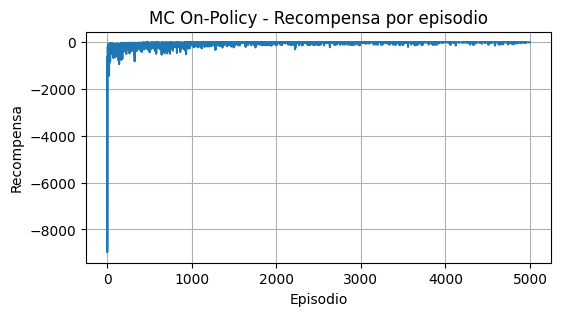

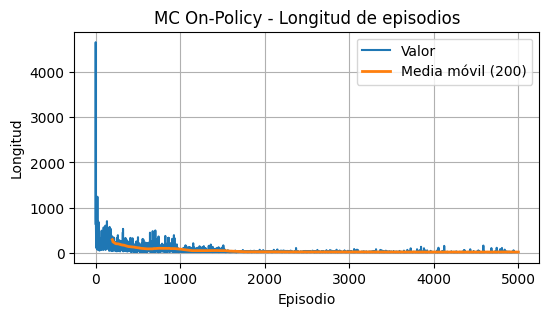

In [5]:
mc_on = MCOnPolicy(
    env,
    epsilon=0.3,
    discount_factor=0.95,
    decay=True
)

mc_on_rewards, mc_on_lengths = mc_on.train(NUM_EPISODES)

plot_curve(
    mc_on_rewards,
    title="MC On-Policy - Recompensa por episodio",
    ylabel="Recompensa"
)

plot_curve(
    mc_on_lengths,
    title="MC On-Policy - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

## Monte Carlo Off-Policy (Importance Sampling)

Entrenando MC off-policy: 100%|██████████| 5000/5000 [00:42<00:00, 117.02it/s]


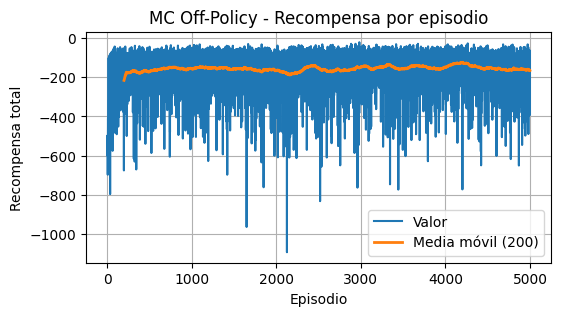

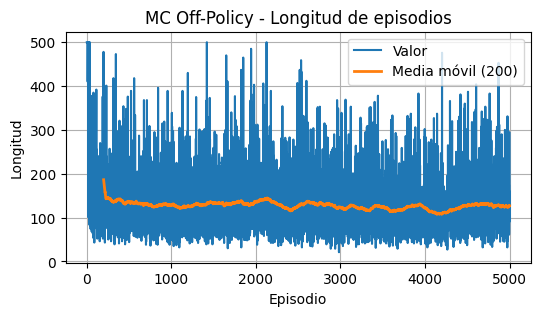

In [6]:
env_off = make_cliff_env(seed=SEED, steps=500)
mc_off = MCOffPolicy(
    env_off,
    discount_factor=0.95,
    epsilon=0.3
)

mc_off_rewards, mc_off_lengths = mc_off.train(NUM_EPISODES)

plot_curve(
    mc_off_rewards,
    title="MC Off-Policy - Recompensa por episodio",
    ylabel="Recompensa total",
    moving_avg_window=200
)

plot_curve(
    mc_off_lengths,
    title="MC Off-Policy - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

## SARSA (On-Policy TD Control)

Entrenando SARSA: 100%|██████████| 5000/5000 [00:13<00:00, 377.18it/s]


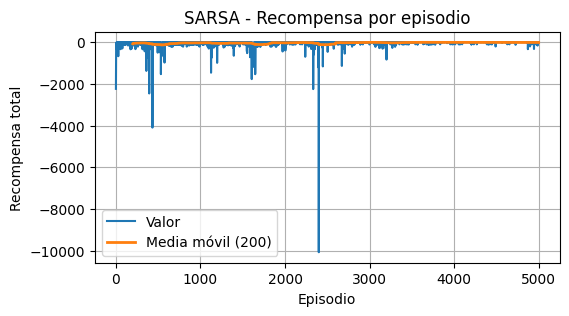

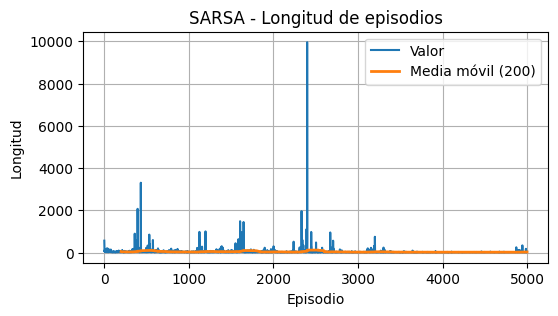

In [7]:
sarsa = SARSA(
    env,
    alpha=0.5,
    discount_factor=0.95,
    epsilon=0.3,
    decay=True
)

sarsa_rewards, sarsa_lengths = sarsa.train(NUM_EPISODES)

plot_curve(
    sarsa_rewards,
    title="SARSA - Recompensa por episodio",
    ylabel="Recompensa total",
    moving_avg_window=200
)

plot_curve(
    sarsa_lengths,
    title="SARSA - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

## Q-Learning (Off-Policy TD Control)

Entrenando Q-Learning: 100%|██████████| 5000/5000 [00:07<00:00, 658.39it/s] 


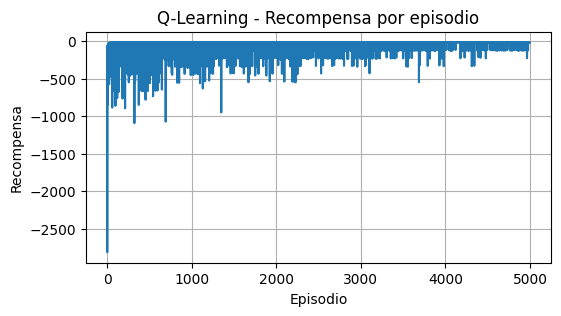

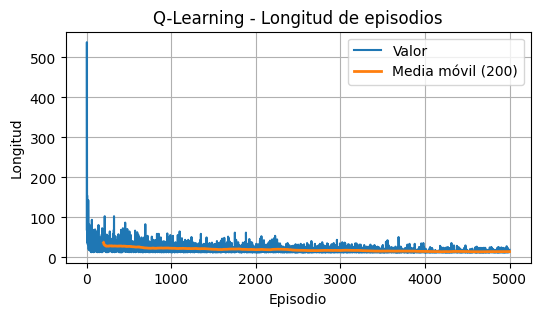

In [8]:
q_learning = QLearning(
    env,
    alpha=0.5,
    discount_factor=0.95,
    epsilon=0.3,
    decay=True
)

q_rewards, q_lengths = q_learning.train(NUM_EPISODES)

plot_curve(
    q_rewards,
    title="Q-Learning - Recompensa por episodio",
    ylabel="Recompensa"
)

plot_curve(
    q_lengths,
    title="Q-Learning - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

## Comparación global de algoritmos

Se comparan las recompensas promedio acumuladas.

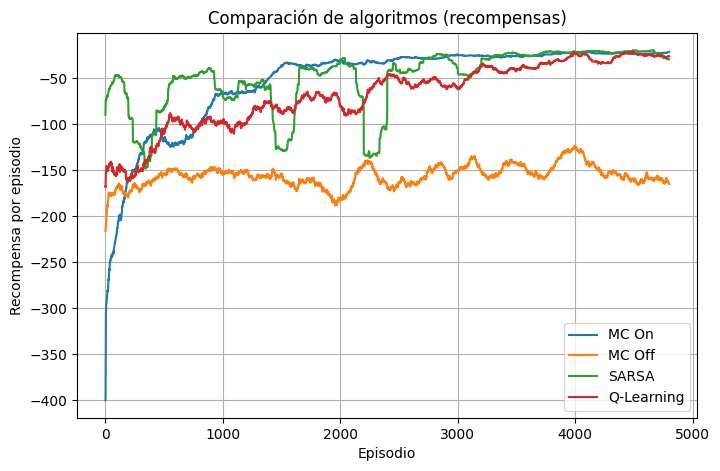

In [9]:
compare_algorithms({
    "MC On": mc_on_rewards,
    "MC Off": mc_off_rewards,
    "SARSA": sarsa_rewards,
    "Q-Learning": q_rewards
}, window=200)

In [10]:
summarize_results("MC On", mc_on_rewards)
summarize_results("MC Off", mc_off_rewards)
summarize_results("SARSA", sarsa_rewards)
summarize_results("Q-Learning", q_rewards)


=== MC On ===
Máximo: -17.00
Media últimos 100: -20.64
Último episodio: -19.00

=== MC Off ===
Máximo: -21.00
Media últimos 100: -166.76
Último episodio: -258.00

=== SARSA ===
Máximo: -17.00
Media últimos 100: -31.99
Último episodio: -45.00

=== Q-Learning ===
Máximo: -13.00
Media últimos 100: -27.67
Último episodio: -19.00


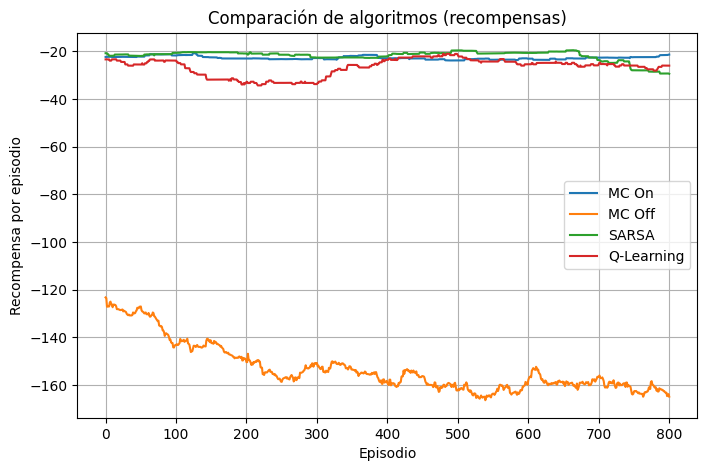

In [11]:
# Últimos 1000 episodios (con media móvil)
compare_algorithms({
    "MC On": mc_on_rewards[-1000:],
    "MC Off": mc_off_rewards[-1000:],
    "SARSA": sarsa_rewards[-1000:],
    "Q-Learning": q_rewards[-1000:]
})

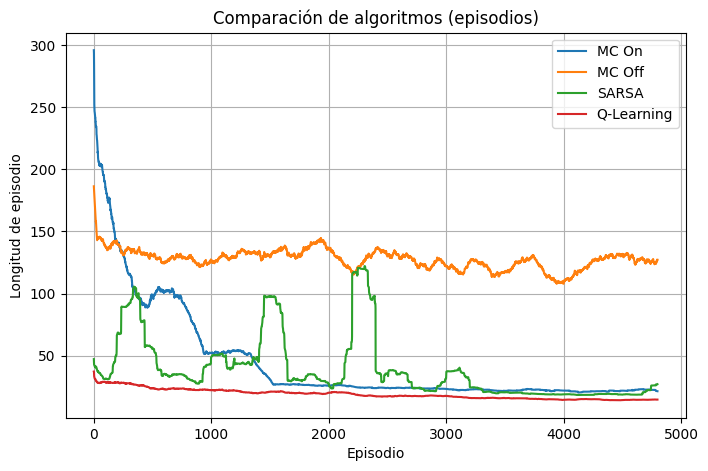

In [12]:
compare_algorithms({
    "MC On": mc_on_lengths,
    "MC Off": mc_off_lengths,
    "SARSA": sarsa_lengths,
    "Q-Learning": q_lengths
}, title= "Comparación de algoritmos (episodios)", y_label="Longitud de episodio", window=200)

## Política greedy aprendida

Se muestra la política final aprendida por cada algoritmo.

In [13]:
print("Política MC On-Policy:")
print(mc_on.greedy_policy())

print("\nPolítica MC Off-Policy:")
print(mc_off.greedy_policy())

print("\nPolítica SARSA:")
print(sarsa.greedy_policy())

print("\nPolítica Q-Learning:")
print(q_learning.greedy_policy())

Política MC On-Policy:
[1 1 2 2 1 1 1 1 1 1 2 2 0 3 1 1 0 1 0 3 3 1 1 2 0 0 0 0 0 0 0 3 0 1 1 2 0
 0 0 0 0 0 0 0 0 0 0 0]

Política MC Off-Policy:
[1 1 0 1 0 1 1 0 1 3 1 2 0 0 1 0 1 0 0 0 0 1 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0]

Política SARSA:
[2 3 1 1 1 1 1 1 1 1 1 2 1 1 1 0 0 0 0 1 0 0 0 2 0 0 0 0 0 0 0 0 3 0 0 2 0
 0 0 0 0 0 0 0 0 0 0 0]

Política Q-Learning:
[2 2 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 2 0
 0 0 0 0 0 0 0 0 0 0 0]


In [14]:
pi, actions, grid = mc_on.greedy_policy_trajectory()
print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", grid)
print()

Política óptima obtenida
 [[0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] 
 Acciones 0, 0, 0, 1, 1, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2 
 Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x





In [15]:
pi_off_grid, actions_off, grid_off = mc_off.greedy_policy_analysis()
print("Política óptima obtenida\n", pi_off_grid)
print("Acciones", actions_off)
print("Para el siguiente grid\n", grid_off)

Política óptima obtenida
 [[0 1 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 0 0 3]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Acciones 1, 1, 0, 1, 0, 1, 1, 0, 1, 3, 1, 2, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x




In [16]:
pi, actions, grid = sarsa.greedy_policy_trajectory()
print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", grid)
print()

Política óptima obtenida
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] 
 Acciones 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2 
 Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x





In [17]:
pi, actions, grid = q_learning.greedy_policy_trajectory()
print("Política óptima obtenida\n", pi, f"\n Acciones {actions } \n Para el siguiente grid\n", grid)
print()

Política óptima obtenida
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] 
 Acciones 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2 
 Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x



